# Predicting House Price

## Dataset

In [110]:
url = "https://raw.githubusercontent.com/SouravG/Housing-price-prediction-using-Regularised-linear-regression/refs/heads/master/Housing%20Price%20data%20set.csv"
import pandas as pd
df = pd.read_csv(url)
df.head()

,Unnamed: 0,price,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
0,1,42000.0,5850,3,1,2,yes,no,yes,no,no,1,no
1,2,38500.0,4000,2,1,1,yes,no,no,no,no,0,no
2,3,49500.0,3060,3,1,1,yes,no,no,no,no,0,no
3,4,60500.0,6650,3,1,2,yes,yes,no,no,no,0,no
4,5,61000.0,6360,2,1,1,yes,no,no,no,no,0,no


In [111]:
df = df.set_index(df.columns[0])
column_x = [i for i in df.columns.tolist() if i != 'price']
column_y = 'price'

print(f"variable x are {", ".join(column_x)}")
print(f"variable y is {column_y}")
print(f"total record in this dataset : {len(df)}")

variable x are lotsize, bedrooms, bathrms, stories, driveway, recroom, fullbase, gashw, airco, garagepl, prefarea
variable y is price
total record in this dataset : 546


| Variable  | Definition |
|----------|------------|
| lotsize  | Size of the land/lot area |
| bedrooms | Number of bedrooms |
| bathrms  | Number of bathrooms |
| stories  | Number of floors in the house |
| driveway | Whether the house has a driveway (Yes/No) |
| recroom  | Whether the house has a recreation room (Yes/No) |
| fullbase | Whether the house has a full basement (Yes/No) |
| gashw    | Whether the house uses gas hot water heating (Yes/No) |
| airco    | Whether the house has air conditioning (Yes/No) |
| garagepl | Number of garage parking spaces |
| prefarea | Whether the house is located in a preferred area (Yes/No) |
| price    | House selling price |

## Assumption

We make assumption that the predictiting of price can be solved using linear model. Since the dataset has one more feature, we use multivariate linear regression

## Test Assumption


### Scatter Plot and Boxplot Plot

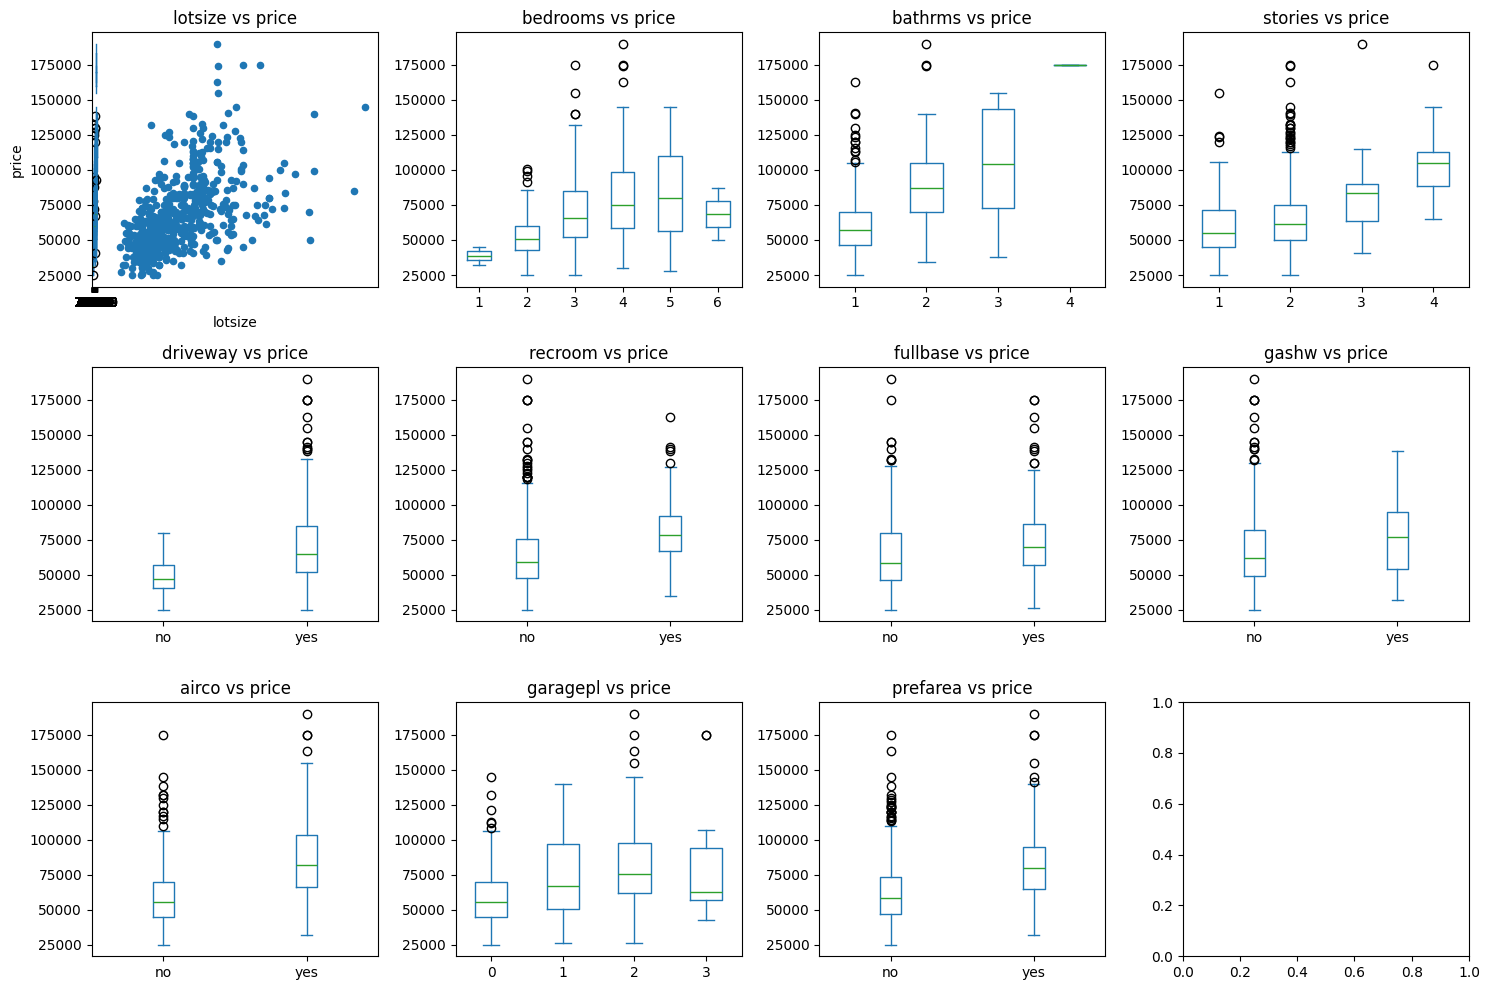

In [112]:
import matplotlib.pyplot as plt
fig,ax = plt.subplots(3,4,figsize=(15,10))
ax = ax.ravel()
for i,j in enumerate(column_x):
    num_uniq = df[j].nunique()
    if num_uniq > 10:
      df.plot(kind='scatter',x=j,y='price',ax=ax[i])
    uniq_val = df[j].unique().tolist()
    sorted_val = sorted(uniq_val)
    df_box = {}
    for k in sorted_val:
        df_box[k] = df[df[j] == k]['price']
    df_final = pd.DataFrame(df_box)
    df_final.plot(kind='box',ax=ax[i])
    ax[i].set_title(f'{j} vs {column_y}')
#
plt.tight_layout()

Based on the result

- Price and lot size seem to have a positive linear relationship, as houses with larger lot sizes generally tend to have higher prices.

- For discrete and binary features, based on the median values shown in the boxplots, many categories show increasing median house prices as the category value increases, suggesting a positive relationship with price. However, this pattern is not consistent for all variables, such as garagepl and bedrooms, where higher category values do not always correspond to higher median price

### Fit the model

##### Spilt Dataset

In [113]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df[column_x], df[column_y], test_size=0.2, random_state=42)

and for train model we need validation dataset so we split train dataset

In [114]:
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

#### Scale Variable

In this dataset there're three type variable:
1. Continous variable
2. Discrete variable
3. Binary variable

Between type of data we will handle differently using various method. For numeric and discrete column we will scale them using z-score method and binary we just convert it into two number 1 (yes) and 0(no)

In [115]:
from sklearn.preprocessing import StandardScaler
numeric = [i for i in column_x if df[i].nunique() != 2 ]
binary = [i for i in column_x if df[i].nunique() == 2 ]

scaler = StandardScaler()
X_train_scaled = X_train_final.copy()
X_val_scaled = X_val.copy()

# replace
X_train_scaled[numeric] = scaler.fit_transform(X_train_scaled[numeric])
X_val_scaled[numeric] = scaler.transform(X_val_scaled[numeric])

X_train_scaled[binary] = X_train_scaled[binary].applymap(lambda x: 1 if x == 'yes' else 0)
X_val_scaled[binary] = X_val_scaled[binary].applymap(lambda x: 1 if x == 'yes' else 0)

X_train_scaled.head()




/tmp/ipykernel_1894/624035231.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_train_scaled[binary] = X_train_scaled[binary].applymap(lambda x: 1 if x == 'yes' else 0)
/tmp/ipykernel_1894/624035231.py:14: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_val_scaled[binary] = X_val_scaled[binary].applymap(lambda x: 1 if x == 'yes' else 0)


,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea
Unnamed: 0,,,,,,,,,,,
13,-1.692241,0.057655,-0.561237,0.202673,1,0,0,0,0,-0.851594,0
476,0.531871,1.490785,1.516533,-0.953562,1,0,1,0,0,0.306042,1
383,3.924204,0.057655,-0.561237,0.202673,1,0,1,0,1,1.463677,1
313,-1.057339,0.057655,-0.561237,0.202673,1,0,1,0,1,-0.851594,0
172,-1.570144,0.057655,-0.561237,-0.953562,0,0,0,1,0,-0.851594,0


In [116]:
print('y_train_final\n')
print(y_train_final.describe())
print('\ny_val\n')
print(y_val.describe())

y_train_final

count       348.000000
mean      68179.574713
std       26732.938049
min       25000.000000
25%       49800.000000
50%       62450.000000
75%       82625.000000
max      175000.000000
Name: price, dtype: float64

y_val

count        88.000000
mean      71935.795455
std       27270.153308
min       31900.000000
25%       51000.000000
50%       64200.000000
75%       85500.000000
max      175000.000000
Name: price, dtype: float64


Based on result above, quality of splitting resul between validation and train_final has not bog difference, it shows that the spred (std) val and train_final almost same and the range also almost same between val and train_final

#### Train Model

In this case we use batch size gradient descent to find optimal value for coefficient and intercept. Because the price has wide range value we use RMSE (root mean square error) as cost function, the formula :

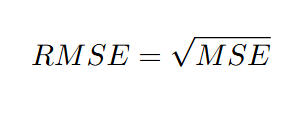


We split data into

In [117]:
import numpy as np
# feature
feature_x_train = X_train_scaled.to_numpy()
feature_x_val = X_val_scaled.to_numpy()

# add bias
feature_x_train_bias = np.c_[np.ones((feature_x_train.shape[0],1)),feature_x_train]
feature_x_val_bias = np.c_[np.ones((feature_x_val.shape[0],1)),feature_x_val]

#init coef
theta_train = np.zeros(feature_x_train_bias.shape[1])
lr = 0.01
epsilon = 1e-6
prev_rmse = float('inf')
final_theta = None

rmse_all_train = []
rmse_all_val = []


for i in range(1000):

  batch_size = 32
  indexs_random  = np.random.permutation(len(feature_x_train_bias))

  rmse_train_epoch = []
  rmse_val_epoch = []

  for j in range(0,len(feature_x_train_bias),batch_size):
    # tran test
    batch_train = feature_x_train_bias[indexs_random[j:j+batch_size]]
    batch_y = y_train_final.iloc[indexs_random[j:j+batch_size]].to_numpy()

    batch_y_pred  = batch_train @ theta_train

    error = batch_y_pred - batch_y
    # update
    gradient = (batch_train.T @ error)/len(batch_y)
    theta_train = theta_train - lr * gradient


  # train
  y_pred_all  = feature_x_train_bias @ theta_train
  error_all = y_pred_all - y_train_final.to_numpy()
  mse_train =  np.sum(error_all**2)/len(y_train_final)
  rmse_train = np.sqrt(mse_train)
  rmse_all_train.append(rmse_train)

  # val
  y_val_pred = feature_x_val_bias @ theta_train
  error_val = y_val_pred - y_val.to_numpy()
  mse_val =  np.sum(error_val**2)/len(y_val)
  rmse_val = np.sqrt(mse_val)
  rmse_all_val.append(rmse_val)







and we plot process of mini batch gradient descent

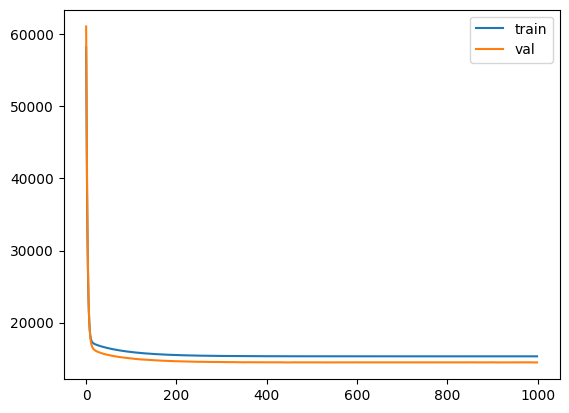

In [118]:
import matplotlib.pyplot as plt
plt.plot(rmse_all_train,label='train')
plt.plot(rmse_all_val,label='val')
plt.legend()
plt.show()

Based on the results, the RMSE values for both the training and validation sets decrease and converge until the final epoch. This indicates that the model learns properly and does not show signs of overfitting, since the validation error remains close to the training error.



#### Evaluation

In this case, we use MAPE (Mean Absolute Percentage Error) for evaluation model performances, the formula :

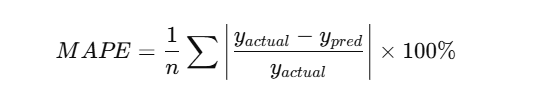


In [119]:
y_pred_val = feature_x_val_bias @ theta_train
y_pred_train = feature_x_train_bias @ theta_train

MAPE_train_linear = np.mean(np.abs((y_train_final.to_numpy() - y_pred_train) / y_train_final.to_numpy())) * 100
MAPE_val_linear = np.mean(np.abs((y_val.to_numpy() - y_pred_val) / y_val.to_numpy())) * 100

print(f"model linear regression MAPE value training : {MAPE_train_linear} %")
print(f"model linear regression MAPE value validation : {MAPE_val_linear} %")

model linear regression MAPE value training : 17.983475964481734 %
model linear regression MAPE value validation : 15.37212819397254 %


The learning curves show that the model converges properly without signs of overfitting, since the training and validation errors remain close to each other. Based on the validation MAPE of 15.35%, the model achieves moderate to reasonably good predictive accuracy, meaning that the average prediction error is approximately 15% relative to the actual target value.

### Other Option

We want to increase model accuracy by decrease error so we will using other model such as

#### Poynomial Features

In [120]:
# prepare
X_train_poly = X_train_final.copy()
X_val_poly = X_val.copy()

# biner
binary = [i for i in df.columns.tolist() if i != 'price' and X_train_poly[i].nunique() == 2]
X_train_poly[binary] = X_train_poly[binary].applymap(lambda x: 1 if x == 'yes' else 0)
X_val_poly[binary] = X_val_poly[binary].applymap(lambda x: 1 if x == 'yes' else 0)

# numeric
# polynomial
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(
    degree=3,
    include_bias=False
)

numeric = [i for i in df.columns.tolist() if i != 'price' and X_train_poly[i].nunique() != 2]

# tranform
X_train_numeric_poly = poly.fit_transform(X_train_poly[numeric])
X_val_numeric_poly = poly.transform(X_val_poly[numeric])

# df
poly_cpl = poly.get_feature_names_out(numeric)

df_X_train_numeric_poly = pd.DataFrame(
    X_train_numeric_poly,
    columns=poly_cpl,
    index=X_train_poly.index
)

df_X_val_numeric_poly = pd.DataFrame(
    X_val_numeric_poly,
    columns=poly_cpl,
    index=X_val_poly.index
)

# concat
df_train_poly_final = pd.concat([df_X_train_numeric_poly,X_train_poly[binary]],axis=1)
df_val_poly_final = pd.concat([df_X_val_numeric_poly,X_val_poly[binary]],axis=1)

# same order
df_val_poly_final = df_val_poly_final.reindex(columns=df_train_poly_final.columns)


#numeric_new
numeric_new = [i for i in df_train_poly_final.columns.tolist() if df_train_poly_final[i].nunique() != 2 ]



/tmp/ipykernel_1894/1632699156.py:7: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_train_poly[binary] = X_train_poly[binary].applymap(lambda x: 1 if x == 'yes' else 0)
/tmp/ipykernel_1894/1632699156.py:8: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_val_poly[binary] = X_val_poly[binary].applymap(lambda x: 1 if x == 'yes' else 0)


In code above we prepare the feature first using polynomiial feature. We add polynomial only numeric type variable because when we also applying it to binary variable the result is not add useful information for model.

In [121]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_poly_scaled = df_train_poly_final.copy()
X_val_poly_scaled = df_val_poly_final.copy()

# replace
X_train_poly_scaled[numeric_new] = scaler.fit_transform(X_train_poly_scaled[numeric_new])
X_val_poly_scaled[numeric_new] = scaler.transform(X_val_poly_scaled[numeric_new])



In [122]:
def mini_batch_gradient(X_train_scaled,X_val_scaled,batch_size):
  import numpy as np
  # feature
  feature_x_train = X_train_scaled.to_numpy()
  feature_x_val = X_val_scaled.to_numpy()

  # add bias
  feature_x_train_bias = np.c_[np.ones((feature_x_train.shape[0],1)),feature_x_train]
  feature_x_val_bias = np.c_[np.ones((feature_x_val.shape[0],1)),feature_x_val]

  # init theta
  #init coef
  theta_train = np.zeros(feature_x_train_bias.shape[1])
  rmse_all_train = []
  rmse_all_val = []


  for i in range(1000):

    batch_size = batch_size
    indexs_random  = np.random.permutation(len(feature_x_train_bias))

    rmse_train_epoch = []
    rmse_val_epoch = []

    for j in range(0,len(feature_x_train_bias),batch_size):
      # tran test
      batch_train = feature_x_train_bias[indexs_random[j:j+batch_size]]
      batch_y = y_train_final.iloc[indexs_random[j:j+batch_size]].to_numpy()

      batch_y_pred  = batch_train @ theta_train

      error = batch_y_pred - batch_y
      # update
      gradient = (batch_train.T @ error)/len(batch_y)
      theta_train = theta_train - lr * gradient


    # train
    y_pred_all  = feature_x_train_bias @ theta_train
    error_all = y_pred_all - y_train_final.to_numpy()
    mse_train =  np.sum(error_all**2)/len(y_train_final)
    rmse_train = np.sqrt(mse_train)
    rmse_all_train.append(rmse_train)

    # val
    y_val_pred = feature_x_val_bias @ theta_train
    error_val = y_val_pred - y_val.to_numpy()
    mse_val =  np.sum(error_val**2)/len(y_val)
    rmse_val = np.sqrt(mse_val)
    rmse_all_val.append(rmse_val)

  return rmse_all_train,rmse_all_val,theta_train






In [123]:
rmse_poly_train,rmse_poly_val,final_theta_poly = mini_batch_gradient(X_train_poly_scaled,X_val_poly_scaled,32)

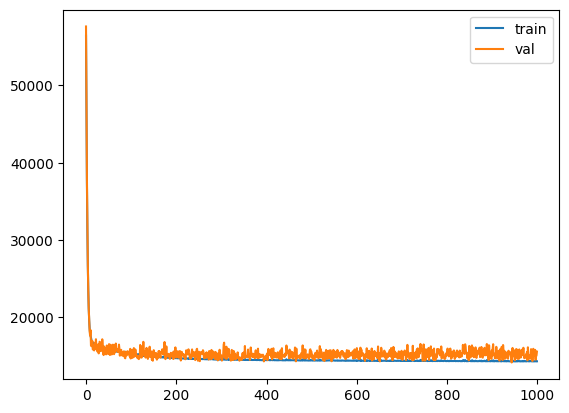

In [124]:
import matplotlib.pyplot as plt
plt.plot(rmse_poly_train,label='train')
plt.plot(rmse_poly_val,label='val')
plt.legend()
plt.show()

In [125]:
# add bias
feature_x_val_poly = np.c_[np.ones(X_val_poly_scaled.shape[0]),X_val_poly_scaled]

# pred
y_val_poly = feature_x_val_poly @ final_theta_poly

MAPE_poly = np.mean(np.abs((y_val.to_numpy() - y_val_poly) / y_val.to_numpy())) * 100

print(f"Model polynomial feature degree 3 MAPE {MAPE_poly} % ")



Model polynomial feature degree 3 MAPE 15.290363130754711 % 


Polynomial feature expansion with degree 3 successfuly improve the accuracy from baseline model (15.345378939301616 %) to 14.541241250412568 %

#### Checking Possible Causes

Although the model does not show signs of overfitting and demonstrates stable convergence, the prediction error remains at a moderate level. Possible reasons include:

• The baseline linear model may be too simple to fully capture the relationship between the input features and the target. This is supported by the slight improvement in MAPE after applying a more complex polynomial model.

• The available input variables may not be sufficiently informative to fully explain the variation in the target variable.

- Missing important features
- Outliers
- Optimatizaion Setup
- Can't capture hidden pattern, for example non-linear relationship


In this case we want to add additional feature (feature engineering) and transform variable to check if this approach can reduced the error or not

###### Feature Engineering
Feature engineering is an approach to creating new features from the existing dataset to improve the prediction of the target variable y.


In [126]:
X_train_final.columns.tolist()

['lotsize',
 'bedrooms',
 'bathrms',
 'stories',
 'driveway',
 'recroom',
 'fullbase',
 'gashw',
 'airco',
 'garagepl',
 'prefarea']

In a feature engineering, based on type feature engineering can divide such as
1. Agregate feature
2. Binary feature
3. Ratio feature

In this case, we adding new aggreagate feature namely as total rooms from bedroom and bathroom and area per bedroom

In [127]:
X_train_final_feature = X_train_final.copy()
X_val_final_feature = X_val.copy()

# add feature
X_train_final_feature['total_rooms'] = X_train_final_feature['bedrooms'] + X_train_final_feature['bathrms']
X_val_final_feature['total_rooms'] = X_val_final_feature['bedrooms'] + X_val_final_feature['bathrms']

X_train_final_feature['area_per_bedroom'] = X_train_final_feature['lotsize'] / X_train_final_feature['total_rooms']
X_val_final_feature['area_per_bedroom'] = X_val_final_feature['lotsize'] / X_val_final_feature['total_rooms']

X_val_final_feature.head()

,lotsize,bedrooms,bathrms,stories,driveway,recroom,fullbase,gashw,airco,garagepl,prefarea,total_rooms,area_per_bedroom
Unnamed: 0,,,,,,,,,,,,,
167,3410,3,1,2,no,no,no,no,yes,0,no,4,852.500000
458,6000,3,2,4,yes,yes,yes,no,yes,0,yes,5,1200.000000
434,11410,2,1,2,yes,no,no,no,no,0,yes,3,3803.333333
48,3090,3,1,2,no,no,no,no,no,0,no,4,772.500000
129,4560,3,2,2,yes,yes,yes,no,yes,1,no,5,912.000000


And then we add polynomial features degree = 2

In [128]:
numeric = [i for i in X_train_final_feature.columns.tolist() if i != 'price' and X_train_final_feature[i].nunique() != 2]
binary = [i for i in X_train_final_feature.columns.tolist() if i != 'price' and X_train_final_feature[i].nunique() == 2]

from sklearn.preprocessing import PolynomialFeatures,StandardScaler
poly = PolynomialFeatures(degree=3,include_bias=False)

X_train_poly_feature = poly.fit_transform(X_train_final_feature[numeric])
X_val_poly_feature = poly.transform(X_val_final_feature[numeric])

X_train_poly_feature_scaled = X_train_poly_feature.copy()
X_val_poly_feature_scaled = X_val_poly_feature.copy()

col = poly.get_feature_names_out(numeric)


df_X_train_poly_feature_numeric_scaled = pd.DataFrame(
    X_train_poly_feature_scaled,
    columns=col,
    index=X_train_final_feature.index
)
df_X_train_poly_concat = pd.concat([df_X_train_poly_feature_numeric_scaled,X_train_final_feature[binary]],axis=1)

df_X_val_poly_feature_numeric_scaled = pd.DataFrame(
    X_val_poly_feature_scaled,
    columns=col,
    index=X_val_final_feature.index
)
df_X_val_poly_concat = pd.concat([df_X_val_poly_feature_numeric_scaled,X_val_final_feature[binary]],axis=1)

# scale
scaler = StandardScaler()
df_X_train_poly_concat_scaled = df_X_train_poly_concat.copy()
df_X_val_poly_concat_scaled = df_X_val_poly_concat.copy()

df_X_train_poly_concat_scaled[col] = scaler.fit_transform(df_X_train_poly_concat_scaled[col])
df_X_val_poly_concat_scaled[col] = scaler.transform(df_X_val_poly_concat_scaled[col])

#map
df_X_val_poly_concat_scaled[binary] = df_X_val_poly_concat_scaled[binary].applymap(lambda x : 1 if x=='yes' else 0)
df_X_train_poly_concat_scaled[binary] = df_X_train_poly_concat_scaled[binary].applymap(lambda x : 1 if x=='yes' else 0)








/tmp/ipykernel_1894/3890579535.py:39: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_X_val_poly_concat_scaled[binary] = df_X_val_poly_concat_scaled[binary].applymap(lambda x : 1 if x=='yes' else 0)
/tmp/ipykernel_1894/3890579535.py:40: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_X_train_poly_concat_scaled[binary] = df_X_train_poly_concat_scaled[binary].applymap(lambda x : 1 if x=='yes' else 0)


In [129]:
rmse_poly_train_feature,rmse_poly_val_feature,final_theta_poly_feature = mini_batch_gradient(df_X_train_poly_concat_scaled,df_X_val_poly_concat_scaled,32)

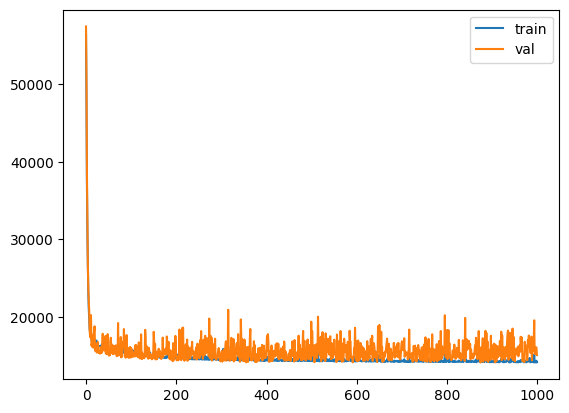

In [130]:
import matplotlib.pyplot as plt
plt.plot(rmse_poly_train_feature,label='train')
plt.plot(rmse_poly_val_feature,label='val')
plt.legend()
plt.show()

In [131]:
# add bias
feature_x_val_poly_final = np.c_[np.ones(df_X_val_poly_concat_scaled.to_numpy().shape[0]),df_X_val_poly_concat_scaled.to_numpy()]

# pred
y_val_poly_pred = feature_x_val_poly_final @ final_theta_poly_feature

MAPE_poly = np.mean(np.abs((y_val.to_numpy() - y_val_poly_pred) / y_val.to_numpy())) * 100

print(f"Model polynomial feature degree 3 MAPE {MAPE_poly} % ")



Model polynomial feature degree 3 MAPE 15.319380880384381 % 


Compared with the baseline linear regression model and the manually engineered features, the polynomial regression model with degree 3 achieves the best predictive performance. The validation MAPE decreases from 15.35% in the baseline linear regression model to 14.54% with polynomial degree 3, while the manually engineered features only reduce the MAPE to 15.02%. This suggests that the nonlinear interactions automatically generated by the degree 3 polynomial expansion capture the relationship between the input variables and the target more effectively than the manually designed features in this case.

#### Ridge Regression

Problem: In real-world applications, linear regression can be used to solve prediction problems. However, its performance (good or poor) can be strongly affected by how closely the input features are related to each other. When two or more features carry very similar information, the model may become confused in assigning their individual contributions, leading to unstable coefficients even if the overall predictions appear similar. So before we fit the model we should check multicolinearity (the relationship between feature x)

##### Multicolinearity

In this step, we checking multicolinearity using two approch
1. correlation matrix (relationship betwenn A vs B feature)
2. Variance influence factor (relationship between A vs combination other features)

A. Correlation Matrix

In [132]:
num = [i for i in df.columns.tolist() if i != 'price' and df[i].nunique() != 2]
df[num].corr()

,lotsize,bedrooms,bathrms,stories,garagepl
lotsize,1.000000,0.151851,0.193833,0.083675,0.352872
bedrooms,0.151851,1.000000,0.373769,0.407974,0.139117
bathrms,0.193833,0.373769,1.000000,0.324066,0.178178
stories,0.083675,0.407974,0.324066,1.000000,0.043412
garagepl,0.352872,0.139117,0.178178,0.043412,1.000000


Based on result we can see that there're weak correlation between two each other feature x, means that we can't use Ridge regression. However, we don't stop here becuase the correlation matrix just compare A vs B and can't using combination feature to finding relationship or A vs B + C + D. So we need other tool to find hidden relationship from feature combination

 B. VIF (Variance influence factor)

 In this approach we applying linear regression between x feature and then calculate VIF from R<sup>2</2>

 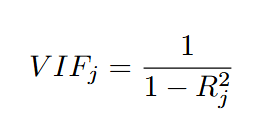

 with j is feature, based on VIF value we can classify a feature is multicolinearyti or not using this rule"



| VIF Value | Interpretation |
|----------|----------------|
| **VIF = 1** | No multicollinearity |
| **1 < VIF < 5** | Low multicollinearity / generally acceptable |
| **5 ≤ VIF < 10** | Moderate multicollinearity / requires attention |
| **VIF ≥ 10** | High / severe multicollinearity |

In [133]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = df[num]

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

    feature        VIF
0   lotsize   6.745811
1  bedrooms  13.675996
2   bathrms   9.151571
3   stories   6.678560
4  garagepl   1.899713


Based on the result, lotsize, bathrooms, and stories have moderate multicolineaity and bedrooms has high multicolinearity. Overall result this dataset seems has multicolinearity that can affected linear regression result

##### Behind Reason using Ridge Regression

We know based on VIF result that the feature has bedrooms hasi highest VIF value with 13.6. In this step we want to drop this feature and fit model for both train and validation to see if multicolineariy impact on error result.Suppose we fit model linear regression in this dataset

In [134]:
X_train_drop = X_train_final.copy()
X_val_drop = X_val.copy()
X_train_drop = X_train_drop.drop(columns=['bedrooms'],axis=1)
X_val_drop = X_val_drop.drop(columns=['bedrooms'],axis=1)

num = [i for i in X_train_drop.columns.tolist() if i != 'price' and X_train_drop[i].nunique() != 2]
binary = [i for i in X_train_drop.columns.tolist() if i != 'price' and X_train_drop[i].nunique() == 2]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_drop_scaled = X_train_drop.copy()
X_train_drop_scaled[num] = scaler.fit_transform(X_train_drop_scaled[num])
X_train_drop_scaled[binary] = X_train_drop_scaled[binary].applymap(lambda x: 1 if x == 'yes' else 0)

X_val_drop_scaled = X_val_drop.copy()
X_val_drop_scaled[num] = scaler.fit_transform(X_val_drop_scaled[num])
X_val_drop_scaled[binary] = X_val_drop_scaled[binary].applymap(lambda x: 1 if x == 'yes' else 0)




/tmp/ipykernel_1894/3575964287.py:13: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_train_drop_scaled[binary] = X_train_drop_scaled[binary].applymap(lambda x: 1 if x == 'yes' else 0)
/tmp/ipykernel_1894/3575964287.py:17: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  X_val_drop_scaled[binary] = X_val_drop_scaled[binary].applymap(lambda x: 1 if x == 'yes' else 0)


In [135]:
rmse_drop_train,rmse_drop_val,final_theta_drop = mini_batch_gradient(X_train_drop_scaled,X_val_drop_scaled,32)

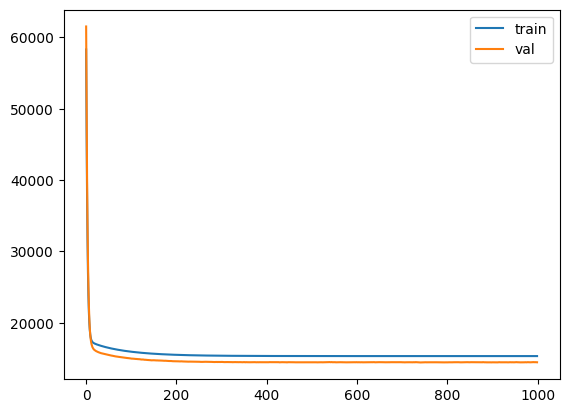

In [136]:
import matplotlib.pyplot as plt
plt.plot(rmse_drop_train,label='train')
plt.plot(rmse_drop_val,label='val')
plt.legend()
plt.show()

In [137]:
feature_x_val_bias_drop = np.c_[np.ones((X_val_drop_scaled.shape[0],1)),X_val_drop_scaled.to_numpy()]
feature_x_train_bias_drop = np.c_[np.ones((X_train_drop_scaled.shape[0],1)),X_train_drop_scaled.to_numpy()]

# pred
y_pred_val_drop = feature_x_val_bias_drop @ final_theta_drop
y_pred_train_drop = feature_x_train_bias_drop @ final_theta_drop

MAPE_drop = np.mean(np.abs((y_val.to_numpy() - y_pred_val_drop) / y_val.to_numpy())) * 100
MAPE_train_drop = np.mean(np.abs((y_train_final.to_numpy() - y_pred_train_drop) / y_train_final.to_numpy())) * 100


print(f"model ridge regression MAPE value in validation: {MAPE_ridge} %")
print(f"model ridge regression MAPE value in training : {MAPE_train_ridge} %")


model ridge regression MAPE value in validation: 14.774171000046483 %
model ridge regression MAPE value in training : 17.980865368959115 %


Based on the result, after dropping the bedrooms feature and retraining the model, the MAPE values for both training and validation remain almost unchanged. This suggests that the bedrooms feature does not provide significant unique information for prediction, because its information is likely already captured by other correlated features (feature redundancy due to multicollinearity).

Therefore, while the model’s predictive performance remains reliable, the interpretation of individual coefficients becomes less reliable, since it is difficult to separate the true contribution of highly correlated features.

If the goal is prediction, this is not necessarily a serious problem. However, if the goal is interpreting the effect of each feature, multicollinearity should be addressed, for example by using Ridge or Lasso regression.

##### Ridge Regression

In [138]:
df_theta = pd.DataFrame()
df_theta['feature'] = ['intercept'] + X_train_ridge_scaled.columns.tolist()
df_theta['theta_run_2'] = final_theta_ridge
df_theta['theta_run_1'] = theta_train
df_theta

,feature,theta_run_2,theta_run_1
0,intercept,51989.740904,51989.051059
1,lotsize,7857.065390,7824.798889
2,bedrooms,1153.355283,1147.646767
3,bathrms,6438.978176,6440.428555
4,stories,6254.720699,6263.488345
5,driveway,7560.501839,7564.301262
6,recroom,2372.064259,2378.107476
7,fullbase,6688.621065,6687.245790
8,gashw,16671.098767,16647.722617
9,airco,12538.802623,12545.709780


we can write the model :

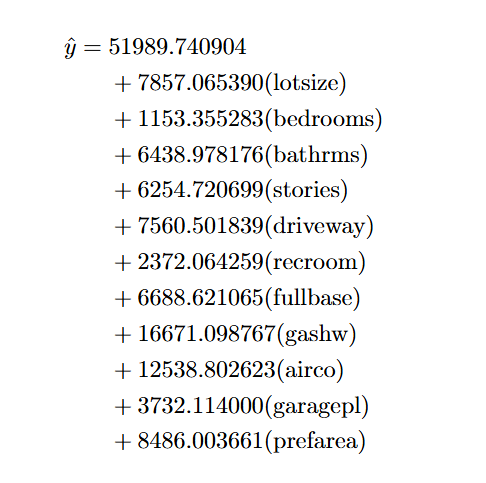

each feature has a coefficient value that represents its contribution to predicting house price. However, because multicollinearity exists in this dataset, several features contain overlapping information. For example, bedrooms and bathrooms may both represent similar aspects of house size. As a result, the individual coefficients of these features are less reliable for interpretation, because the model may have difficulty separating their true contributions.

To address this issue, Ridge regression can be used by adding a regularization term to the cost function. This allows the model not only to minimize prediction error, but also to keep the coefficient values smaller and more stable, which can improve generalization performance.

In the ridge regression we add penalty the formula of penalty ⁉
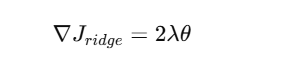

In [139]:
def mini_batch_gradient_ridge(X_train_scaled, X_val_scaled, batch_size, lambda_):
    import numpy as np

    # feature
    feature_x_train = X_train_scaled.to_numpy()
    feature_x_val = X_val_scaled.to_numpy()

    # add bias/intercept
    feature_x_train_bias = np.c_[np.ones((feature_x_train.shape[0], 1)), feature_x_train]
    feature_x_val_bias = np.c_[np.ones((feature_x_val.shape[0], 1)), feature_x_val]

    # init theta
    theta_train = np.zeros(feature_x_train_bias.shape[1])

    rmse_all_train = []
    rmse_all_val = []

    for i in range(1000):

        indexs_random = np.random.permutation(len(feature_x_train_bias))

        for j in range(0, len(feature_x_train_bias), batch_size):

            batch_train = feature_x_train_bias[indexs_random[j:j+batch_size]]
            batch_y = y_train_final.iloc[indexs_random[j:j+batch_size]].to_numpy()

            batch_y_pred = batch_train @ theta_train
            error = batch_y_pred - batch_y

            # gradient linear regression
            gradient = (batch_train.T @ error) / len(batch_y)

            # ridge penalty
            ridge_penalty = 2 * lambda_ * theta_train
            ridge_penalty[0] = 0  # intercept tidak dihukum

            # gradient ridge
            gradient = gradient + ridge_penalty

            # update theta
            theta_train = theta_train - lr * gradient

        # train RMSE
        y_pred_all = feature_x_train_bias @ theta_train
        error_all = y_pred_all - y_train_final.to_numpy()
        mse_train = np.mean(error_all**2)
        rmse_train = np.sqrt(mse_train)
        rmse_all_train.append(rmse_train)

        # validation RMSE
        y_val_pred = feature_x_val_bias @ theta_train
        error_val = y_val_pred - y_val.to_numpy()
        mse_val = np.mean(error_val**2)
        rmse_val = np.sqrt(mse_val)
        rmse_all_val.append(rmse_val)

    return rmse_all_train, rmse_all_val, theta_train

In this ridge we want use gridSearch to use diffetent lambda value and get the best result and then compare to baseline model

In [140]:
lambda_list = [0, 0.001, 0.01, 0.1, 1, 10, 100]

results = []

for lambda_ in lambda_list:
    rmse_train, rmse_val, final_theta = mini_batch_gradient_ridge(
        X_train_scaled,
        X_val_scaled,
        batch_size=32,
        lambda_=lambda_
    )

    # prepare feature + bias
    X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled.to_numpy()]
    X_val_bias = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled.to_numpy()]

    # predict using final theta
    y_train_pred = X_train_bias @ final_theta
    y_val_pred = X_val_bias @ final_theta

    # MAPE
    train_mape = np.mean(np.abs((y_train_final.to_numpy() - y_train_pred) / y_train_final.to_numpy())) * 100
    val_mape = np.mean(np.abs((y_val.to_numpy() - y_val_pred) / y_val.to_numpy())) * 100

    results.append({
        "lambda": lambda_,
        "train_mape": train_mape,
        "val_mape": val_mape,
        "final_theta": final_theta
    })

In [144]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.DataFrame(results).drop(columns=["final_theta"]).round(2)

,lambda,train_mape,val_mape
0,0.00,17.99,15.39
1,0.00,17.95,15.30
2,0.01,17.88,14.96
3,0.10,18.77,14.71
4,1.00,24.93,19.41
5,10.00,32.60,27.66
6,100.00,15289412013167735725144005752320510292777126128...,15779068086278042291596487986986512842883239689...


##### Interpretation

Based on the results, using different lambda values in Ridge regression does not significantly improve the validation MAPE compared with the baseline linear regression model. The best validation MAPE remains around 14%, which indicates that regularization does not substantially improve predictive performance in this case.

#### Lasso Regression

In ridge regression, we add penalty to gradient so we can decrease coefficeint and become more stable. In lasso regression we set the coefficient become zero for some features in dataset

The gradient in gradient descent become ⁉

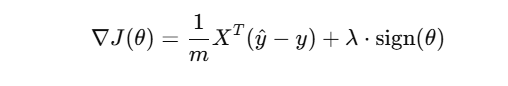

In [145]:
def mini_batch_gradient_lasso(X_train_scaled, X_val_scaled, batch_size, lambda_):
    import numpy as np

    # feature
    feature_x_train = X_train_scaled.to_numpy()
    feature_x_val = X_val_scaled.to_numpy()

    # add bias/intercept
    feature_x_train_bias = np.c_[np.ones((feature_x_train.shape[0], 1)), feature_x_train]
    feature_x_val_bias = np.c_[np.ones((feature_x_val.shape[0], 1)), feature_x_val]

    # init theta
    theta_train = np.zeros(feature_x_train_bias.shape[1])

    rmse_all_train = []
    rmse_all_val = []

    for i in range(1000):

        indexs_random = np.random.permutation(len(feature_x_train_bias))

        for j in range(0, len(feature_x_train_bias), batch_size):

            batch_train = feature_x_train_bias[indexs_random[j:j+batch_size]]
            batch_y = y_train_final.iloc[indexs_random[j:j+batch_size]].to_numpy()

            batch_y_pred = batch_train @ theta_train
            error = batch_y_pred - batch_y

            # gradient linear regression
            gradient = (batch_train.T @ error) / len(batch_y)

            # ridge penalty
            lasso_penalty = lambda_ * np.sign(theta_train)
            lasso_penalty[0] = 0  # intercept tidak dihukum

            # gradient ridge
            gradient = gradient + lasso_penalty

            # update theta
            theta_train = theta_train - lr * gradient

        # train RMSE
        y_pred_all = feature_x_train_bias @ theta_train
        error_all = y_pred_all - y_train_final.to_numpy()
        mse_train = np.mean(error_all**2)
        rmse_train = np.sqrt(mse_train)
        rmse_all_train.append(rmse_train)

        # validation RMSE
        y_val_pred = feature_x_val_bias @ theta_train
        error_val = y_val_pred - y_val.to_numpy()
        mse_val = np.mean(error_val**2)
        rmse_val = np.sqrt(mse_val)
        rmse_all_val.append(rmse_val)

    return rmse_all_train, rmse_all_val, theta_train

and then we will use different lambda like ridge regression

In [147]:
lambda_list = [0, 0.001, 0.01, 0.1, 1, 10, 100]

results_lasso = []

for lambda_ in lambda_list:
    rmse_train, rmse_val, final_theta = mini_batch_gradient_lasso(
        X_train_scaled,
        X_val_scaled,
        batch_size=32,
        lambda_=lambda_
    )

    # prepare feature + bias
    X_train_bias = np.c_[np.ones((X_train_scaled.shape[0], 1)), X_train_scaled.to_numpy()]
    X_val_bias = np.c_[np.ones((X_val_scaled.shape[0], 1)), X_val_scaled.to_numpy()]

    # predict using final theta
    y_train_pred = X_train_bias @ final_theta
    y_val_pred = X_val_bias @ final_theta

    # MAPE
    train_mape = np.mean(np.abs((y_train_final.to_numpy() - y_train_pred) / y_train_final.to_numpy())) * 100
    val_mape = np.mean(np.abs((y_val.to_numpy() - y_val_pred) / y_val.to_numpy())) * 100

    results_lasso.append({
        "lambda": lambda_,
        "train_mape": train_mape,
        "val_mape": val_mape,
        "final_theta": final_theta
    })

In [148]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)
pd.DataFrame(results_lasso).drop(columns=["final_theta"]).round(2)

,lambda,train_mape,val_mape
0,0.00,17.96,15.35
1,0.00,17.96,15.36
2,0.01,17.98,15.39
3,0.10,17.98,15.37
4,1.00,17.94,15.34
5,10.00,17.98,15.33
6,100.00,17.92,15.12


Based on the results, there is no significant improvement in validation MAPE after applying Lasso regression. This indicates that although some features contain overlapping information, they still provide useful predictive information for estimating house prices.

Since Lasso forces some coefficients toward zero, some potentially useful features may be effectively removed from the model. As a result, the model may lose important information, which explains why Lasso does not improve prediction performance in this case.

## Conclusion
We conclude that the best model to predicting house price using x variable like bedroom, bathroom, and many more for this dataset is using Polynomial features degree = 3 with MAPE result ~14.00 % error from relative y variable